In [16]:
%pip install pandas
%pip install matplotlib
%pip install numpy

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# JSON Error Analysis Template

**Created:** 2025-08-13 15:04 UTC

This notebook helps you analyze per-UID model outcomes stored as JSON files, where:
- Each *format* has its own folder, e.g. `results/formatA/`, `results/formatB/`.
- Within each format folder, each *model* has its own JSON file, e.g. `model1.json`, `model2.json`.
- Each JSON file contains outcomes keyed by UID (or a list of objects with a UID field), including a field that indicates success or failure.

You can adapt the config section below to your structure and field names.


## Expected layout (example)

```
results/
  formatA/
    model_alpha.json
    model_beta.json
  formatB/
    model_alpha.json
    model_beta.json
```

You can change file patterns and field names in the config cell.


In [17]:
# === CONFIG: EDIT THIS TO MATCH YOUR PROJECT ===
from pathlib import Path

# Root directory containing format subfolders
BASE_DIR = Path("results_dir_parsed/zebra-grid-mini")  # e.g., Path("path/to/results")

# The set of formats (subfolder names under BASE_DIR)
FORMATS = ["json", "xml"]  # e.g., ["jsonl_short", "jsonl_long"]

# The set of model files (filenames) present in each format folder
MODELS = ["meta-llama_Llama-3.1-8B-Instruct.json", 
          "mistralai_Mistral-7B-Instruct-v0.1.json",
          "Qwen_Qwen2.5-7B-Instruct.json",
          "Qwen_Qwen2.5-14B-Instruct.json",
          "Qwen_Qwen2.5-Math-7B-Instruct.json",
          "Qwen_Qwen2.5-coder-14B-Instruct.json"]

# How to find each model file (relative to the format folder)
# You can also use patterns like "{format}/{model}" if you prefer strings.
# We will build paths as: BASE_DIR / format_name / model_file
FILE_IS_OPTIONAL = False  # if True, missing model files won't raise

# How to read JSON results:
# Supported shapes:
#   1) dict of {uid: {...}}  (set uid_key to None to use outer keys as UIDs)
#   2) list of {..., uid_key: <uid>, success_key: <value>, ...}
UID_KEY = "id"          # set to None if UIDs are the outer JSON keys
SUCCESS_KEY = "solved"  # field name in each record that indicates success/failure
PUZZLE_KEY = "puzzle" # field name in each record that contains the puzzle text
GOLD_ANSWER_KEY = "solution" # field name in each record that contains the gold answer
REASONING_KEY = "reasoning"  # field name in each record that contains the reasoning text
CORRECT_CELLS_KEY = "correct_cells"  # field name in each record that contains the correct cells
TOTAL_CELLS_KEY = "total_cells"  # field name in each record that contains the total cells
PARSED_KEY = "parsed"  # field name in each record that contains the parsed data

# What values count as 'success'?
SUCCESS_VALUES = {True}

# Optional: if success is nested (e.g., record["metrics"]["exact_match"])
# you can provide a small accessor function later. For now we assume SUCCESS_KEY is top-level.


In [23]:
# === UTILITIES (don't edit unless needed) ===
import json
import pandas as pd

#!/usr/bin/env python3
import argparse
import json
from pathlib import Path
from typing import Dict, Any, List, Tuple

import pandas as pd

# ========== CONFIG (edit if your column names differ) ==========
UID_COL = "uid"                 # UID column in the parquet and UID CSV (fallback to first col if missing)
QUESTION_COL = "question"       # question text column in the parquet
GOLD_ANSWER_COL = "answer"      # gold/true answer column in the parquet

# Keys expected inside model JSON for each UID/record
JSON_UID_KEY = "uid"            # set to None if JSON is a dict keyed by UID
JSON_SUCCESS_KEY = "success"
JSON_REASONING_KEY = "reasoning"
JSON_CORRECT_CELLS_KEY = "correct_cells"
JSON_TOTAL_CELLS_KEY = "total_cells"

SUCCESS_VALUES = {True, 1, "success", "correct", "ok", "true", "True"}

# ===============================================================

def read_uid_csv(path: Path) -> pd.Index:
    df = pd.read_csv(path)
    if UID_COL in df.columns:
        uids = df[UID_COL].astype(str)
    else:
        # fall back to first column if no 'uid' header
        first = df.columns[0]
        uids = df[first].astype(str)
    return pd.Index(uids.unique())

def read_parquet_gold(path: Path) -> pd.DataFrame:
    df = pd.read_parquet(path)
    # make UID string-like to match CSV
    if UID_COL not in df.columns:
        raise ValueError(f"Parquet is missing required column: {UID_COL}")
    return df.assign(**{UID_COL: df[UID_COL].astype(str)})

def coerce_bool_success(val: Any) -> bool:
    return val in SUCCESS_VALUES

def parse_model_json(path: Path,
                     model_name: str = None) -> pd.DataFrame:
    """
    Returns a DataFrame indexed by UID with columns:
      ['model','success','reasoning','correct_cells','total_cells']
    """
    with open(path, "r", encoding="utf-8") as f:
        obj = json.load(f)

    rows: List[Dict[str, Any]] = []

    if isinstance(obj, dict) and JSON_UID_KEY is None:
        # dict keyed by UID
        for uid, rec in obj.items():
            if not isinstance(rec, dict):
                # allow bare boolean success
                rec = {JSON_SUCCESS_KEY: rec}
            rows.append({
                UID_COL: str(uid),
                "success": coerce_bool_success(rec.get(JSON_SUCCESS_KEY)),
                "reasoning": rec.get(JSON_REASONING_KEY),
                "correct_cells": rec.get(JSON_CORRECT_CELLS_KEY),
                "total_cells": rec.get(JSON_TOTAL_CELLS_KEY),
            })
    elif isinstance(obj, list) and JSON_UID_KEY:
        for rec in obj:
            if not isinstance(rec, dict) or JSON_UID_KEY not in rec:
                continue
            rows.append({
                UID_COL: str(rec[JSON_UID_KEY]),
                "success": coerce_bool_success(rec.get(JSON_SUCCESS_KEY)),
                "reasoning": rec.get(JSON_REASONING_KEY),
                "correct_cells": rec.get(JSON_CORRECT_CELLS_KEY),
                "total_cells": rec.get(JSON_TOTAL_CELLS_KEY),
            })
    else:
        raise ValueError(
            "JSON shape not supported by current config. "
            "If your JSON is dict keyed by UID, set JSON_UID_KEY=None. "
            "If it's a list of records, set JSON_UID_KEY to the UID field name."
        )

    df = pd.DataFrame(rows).set_index(UID_COL)
    if model_name is None:
        model_name = path.stem
    df.insert(0, "model", model_name)
    return df

def load_models(model_specs: List[str]) -> pd.DataFrame:
    """
    model_specs entries can be:
      - /path/to/model_alpha.json
      - model_name=/path/to/file.json   (lets you rename columns nicely)
    Returns concatenated DF indexed by UID with a 'model' column.
    """
    frames = []
    for spec in model_specs:
        if "=" in spec:
            model_name, path_str = spec.split("=", 1)
        else:
            model_name, path_str = None, spec
        dfm = parse_model_json(Path(path_str), model_name=model_name)
        frames.append(dfm)
    if not frames:
        raise ValueError("No model JSONs provided.")
    return pd.concat(frames, axis=0, copy=False)

def build_inspection_table(
    gold_df: pd.DataFrame,
    uid_list: pd.Index,
    models_df: pd.DataFrame,
    only_incorrect: bool = True
) -> pd.DataFrame:
    # slice gold to requested UIDs, keep only relevant columns
    gold_view = gold_df.set_index(UID_COL).reindex(uid_list)[[QUESTION_COL, GOLD_ANSWER_COL]]

    # restrict models_df to those UIDs; if only_incorrect, keep success == False
    subset = models_df.loc[models_df.index.intersection(uid_list)]
    if only_incorrect:
        subset = subset[subset["success"] == False]

    # merge (many models per UID) -> join gold on index
    merged = subset.join(gold_view, how="left")
    # reorder columns for readability
    cols = [
        QUESTION_COL, GOLD_ANSWER_COL, "model", "success",
        "reasoning", "correct_cells", "total_cells"
    ]
    # some columns may be missing; filter
    cols = [c for c in cols if c in merged.columns]
    merged = merged[cols]
    # bring UID back as a column for export
    merged = merged.reset_index().rename(columns={UID_COL: "uid"})
    return merged




def _safe_read_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def _coerce_bool_success(val):
    return val in SUCCESS_VALUES

def parse_json_to_mapping(obj, uid_key=UID_KEY, success_key=SUCCESS_KEY):
    """Return a dict: {uid: bool_success}.
    Supports:
      - dict of {uid: {..., success_key: value, ...}}
      - list of {..., uid_key: uid, success_key: value, ...}
    """
    out = {}
    if isinstance(obj, dict):
        if uid_key is None:
            # Outer keys are UIDs
            for uid, rec in obj.items():
                if isinstance(rec, dict) and success_key in rec:
                    out[uid] = _coerce_bool_success(rec[success_key])
                else:
                    # If record is already boolean
                    out[uid] = _coerce_bool_success(rec)
        else:
            raise ValueError("For dict-shaped JSON, set UID_KEY=None so outer keys are treated as UIDs.")
    elif isinstance(obj, list):
        if uid_key is None:
            raise ValueError("For list-shaped JSON, set UID_KEY to the field name holding the UID.")
        for rec in obj:
            if not isinstance(rec, dict):
                continue
            if uid_key in rec and success_key in rec:
                out[str(rec[uid_key])] = _coerce_bool_success(rec[success_key])
    else:
        raise ValueError("Unsupported JSON shape. Provide a dict or list.")
    return out

def load_all_results(base_dir, formats, models, file_is_optional=False):
    """Load all (format, model) pairs into a wide DataFrame.
    Columns: MultiIndex (format, model)
    Index: UID (union of all UIDs seen)
    Values: boolean success (True/False) or NaN if missing
    """
    frames = []
    for fmt in formats:
        cols = {}
        for model_file in models:
            path = (base_dir / fmt / model_file)
            if not path.exists():
                if file_is_optional:
                    continue
                else:
                    raise FileNotFoundError(f"Missing: {path}")
            obj = _safe_read_json(path)
            mapping = parse_json_to_mapping(obj, uid_key=UID_KEY, success_key=SUCCESS_KEY)
            s = pd.Series(mapping, name=(fmt, model_file), dtype="boolean")
            cols[(fmt, model_file)] = s
        if cols:
            df_fmt = pd.concat(cols.values(), axis=1)
            frames.append(df_fmt)
    if not frames:
        raise RuntimeError("No data loaded. Check BASE_DIR/FORMATS/MODELS and JSON schema.")
    df = pd.concat(frames, axis=1).sort_index()
    # Ensure columns are a proper MultiIndex
    df.columns = pd.MultiIndex.from_tuples(df.columns, names=["format", "model"])
    return df

def all_models_fail_by_format(df):
    """Return dict: format -> set of UIDs where *all* models in that format failed (False)."""
    out = {}
    for fmt, sub in df.groupby(level="format", axis=1):
        # require all models present and all == False (ignoring NaN -> treat as not success)
        # We'll fillna(False) so NaN counts as failure if you want stricter behavior.
        all_fail = (sub.fillna(False) == False).all(axis=1)
        out[fmt] = set(all_fail[all_fail].index)
    return out

def model_succeeds_in_one_format_not_other(df):
    """
    Return dict:
      model -> { '<fmtA>_not_<fmtB>': {uids}, '<fmtB>_not_<fmtA>': {uids}, ... }
    Computes all pairwise comparisons across formats.
    """
    import itertools

    result = {}
    formats = list(df.columns.get_level_values("format").unique())
    pairs = list(itertools.combinations(formats, 2))

    for model in df.columns.get_level_values("model").unique():
        model_map = {}

        for fa, fb in pairs:
            if (fa, model) not in df.columns or (fb, model) not in df.columns:
                continue

            sa = df[(fa, model)].fillna(False)
            sb = df[(fb, model)].fillna(False)

            # Masks where the same UID is True in one format and not True in the other
            mask_a_not_b = sa & (~sb)
            mask_b_not_a = sb & (~sa)

            uids_a_not_b = set(sa.index[mask_a_not_b])
            uids_b_not_a = set(sb.index[mask_b_not_a])

            model_map[f"{fa}_not_{fb}"] = uids_a_not_b
            model_map[f"{fb}_not_{fa}"] = uids_b_not_a

        if model_map:
            result[model] = model_map

    return result


def export_uid_sets(obj, out_dir="exports", prefix=None):
    """
    Recursively export nested dicts of UID sets (or lists/indices) to CSVs.
    - obj can be: set/list/tuple/Index, or dict of the same (nested arbitrarily).
    - File names include the key path joined by '__', with an optional prefix.
    Returns: list of written file paths.
    """
    import os
    import pandas as pd

    os.makedirs(out_dir, exist_ok=True)
    paths = []

    def walk(node, key_path):
        # Leaf: a collection of UIDs
        if isinstance(node, (set, list, tuple, pd.Index)):
            uids = sorted(map(str, node))
            base = "__".join(map(str, key_path)) if key_path else "uids"
            fname = f"{prefix}__{base}.csv" if prefix else f"{base}.csv"
            fpath = os.path.join(out_dir, fname)
            pd.DataFrame(uids, columns=["uid"]).to_csv(fpath, index=False)
            paths.append(fpath)
            return

        # Nested: keep walking
        if isinstance(node, dict):
            for k, v in node.items():
                walk(v, key_path + [k])

        # Anything else is ignored (scalars etc.)

    walk(obj, [])
    return paths


In [24]:
# === LOAD DATA ===
import pandas as pd

df = load_all_results(BASE_DIR, FORMATS, MODELS, file_is_optional=FILE_IS_OPTIONAL)
print(f"Loaded table with {df.shape[0]} UIDs and {df.shape[1]} (format,model) columns.")
df.head()

Loaded table with 320 UIDs and 12 (format,model) columns.


format                                           json  \
model           meta-llama_Llama-3.1-8B-Instruct.json   
lgp-test-2x2-0                                   True   
lgp-test-2x2-1                                   True   
lgp-test-2x2-10                                  True   
lgp-test-2x2-11                                  True   
lgp-test-2x2-12                                  True   

format                                                   \
model           mistralai_Mistral-7B-Instruct-v0.1.json   
lgp-test-2x2-0                                     True   
lgp-test-2x2-1                                    False   
lgp-test-2x2-10                                    True   
lgp-test-2x2-11                                    True   
lgp-test-2x2-12                                   False   

format                                                                        \
model           Qwen_Qwen2.5-7B-Instruct.json Qwen_Qwen2.5-14B-Instruct.json   
lgp-test-2x2-0                           True                           True   
lgp-test-2x2-1                           True                           True   
lgp-test-2x2-10                          True                           True   
lgp-test-2x2-11                          True                           True   
lgp-test-2x2-12                          True                           True   

format                                              \
model           Qwen_Qwen2.5-Math-7B-Instruct.json   
lgp-test-2x2-0                               False   
lgp-test-2x2-1                               False   
lgp-test-2x2-10                              False   
lgp-test-2x2-11                               True   
lgp-test-2x2-12                               True   

format                                                \
model           Qwen_Qwen2.5-coder-14B-Instruct.json   
lgp-test-2x2-0                                  True   
lgp-test-2x2-1                                  True   
lgp-test-2x2-10                                 True   
lgp-test-2x2-11                                 True   
lgp-test-2x2-12                                 True   

format                                            xml  \
model           meta-llama_Llama-3.1-8B-Instruct.json   
lgp-test-2x2-0                                   True   
lgp-test-2x2-1                                   True   
lgp-test-2x2-10                                  True   
lgp-test-2x2-11                                  True   
lgp-test-2x2-12                                  True   

format                                                   \
model           mistralai_Mistral-7B-Instruct-v0.1.json   
lgp-test-2x2-0                                     True   
lgp-test-2x2-1                                    False   
lgp-test-2x2-10                                    True   
lgp-test-2x2-11                                    True   
lgp-test-2x2-12                                   False   

format                                                                        \
model           Qwen_Qwen2.5-7B-Instruct.json Qwen_Qwen2.5-14B-Instruct.json   
lgp-test-2x2-0                           True                           True   
lgp-test-2x2-1                           True                           True   
lgp-test-2x2-10                          True                           True   
lgp-test-2x2-11                          True                           True   
lgp-test-2x2-12                          True                           True   

format                                              \
model           Qwen_Qwen2.5-Math-7B-Instruct.json   
lgp-test-2x2-0                               False   
lgp-test-2x2-1                                True   
lgp-test-2x2-10                              False   
lgp-test-2x2-11                              False   
lgp-test-2x2-12                              False   

format                                                
model           Qwen_Qwen2.5-coder-14B-Instr

In [25]:
# UIDs where *all models fail* for each format
all_fail = all_models_fail_by_format(df)
for fmt, uids in all_fail.items():
    print(f"Format: {fmt} | #UIDs with all-models-fail: {len(uids)}")

# UIDs where a model succeeds in one format but not the other
model_flip = model_succeeds_in_one_format_not_other(df)
for model, comp in model_flip.items():
    print(f"\nModel: {model}")
    for k, uids in comp.items():
        print(f"  {k}: {len(uids)} UIDs")

Format: json | #UIDs with all-models-fail: 88
Format: xml | #UIDs with all-models-fail: 87

Model: meta-llama_Llama-3.1-8B-Instruct.json
  json_not_xml: 34 UIDs
  xml_not_json: 36 UIDs

Model: mistralai_Mistral-7B-Instruct-v0.1.json
  json_not_xml: 20 UIDs
  xml_not_json: 11 UIDs

Model: Qwen_Qwen2.5-7B-Instruct.json
  json_not_xml: 43 UIDs
  xml_not_json: 32 UIDs

Model: Qwen_Qwen2.5-14B-Instruct.json
  json_not_xml: 36 UIDs
  xml_not_json: 38 UIDs

Model: Qwen_Qwen2.5-Math-7B-Instruct.json
  json_not_xml: 44 UIDs
  xml_not_json: 1 UIDs

Model: Qwen_Qwen2.5-coder-14B-Instruct.json
  json_not_xml: 58 UIDs
  xml_not_json: 30 UIDs


C:\Users\speat\AppData\Local\Temp\ipykernel_4804\3059300562.py:217: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  for fmt, sub in df.groupby(level="format", axis=1):


In [27]:
paths = []
paths += export_uid_sets(all_fail, out_dir="exports", prefix="all_models_fail")
paths += export_uid_sets(model_flip, out_dir="exports", prefix="model_format_flips")

print("Exported:")
for p in paths:
    print(" -", p)


Exported:
 - exports\all_models_fail__json.csv
 - exports\all_models_fail__xml.csv
 - exports\model_format_flips__meta-llama_Llama-3.1-8B-Instruct.json__json_not_xml.csv
 - exports\model_format_flips__meta-llama_Llama-3.1-8B-Instruct.json__xml_not_json.csv
 - exports\model_format_flips__mistralai_Mistral-7B-Instruct-v0.1.json__json_not_xml.csv
 - exports\model_format_flips__mistralai_Mistral-7B-Instruct-v0.1.json__xml_not_json.csv
 - exports\model_format_flips__Qwen_Qwen2.5-7B-Instruct.json__json_not_xml.csv
 - exports\model_format_flips__Qwen_Qwen2.5-7B-Instruct.json__xml_not_json.csv
 - exports\model_format_flips__Qwen_Qwen2.5-14B-Instruct.json__json_not_xml.csv
 - exports\model_format_flips__Qwen_Qwen2.5-14B-Instruct.json__xml_not_json.csv
 - exports\model_format_flips__Qwen_Qwen2.5-Math-7B-Instruct.json__json_not_xml.csv
 - exports\model_format_flips__Qwen_Qwen2.5-Math-7B-Instruct.json__xml_not_json.csv
 - exports\model_format_flips__Qwen_Qwen2.5-coder-14B-Instruct.json__json_not_x

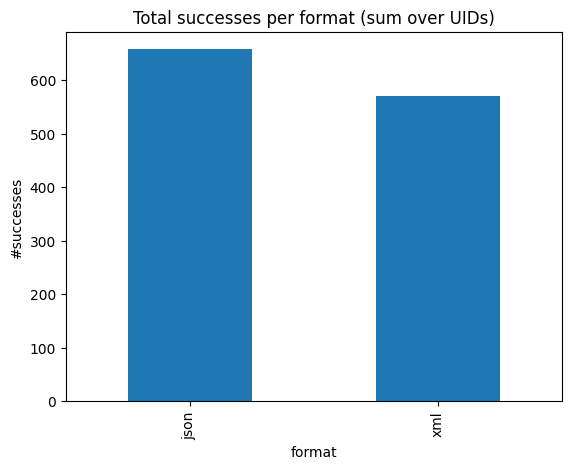

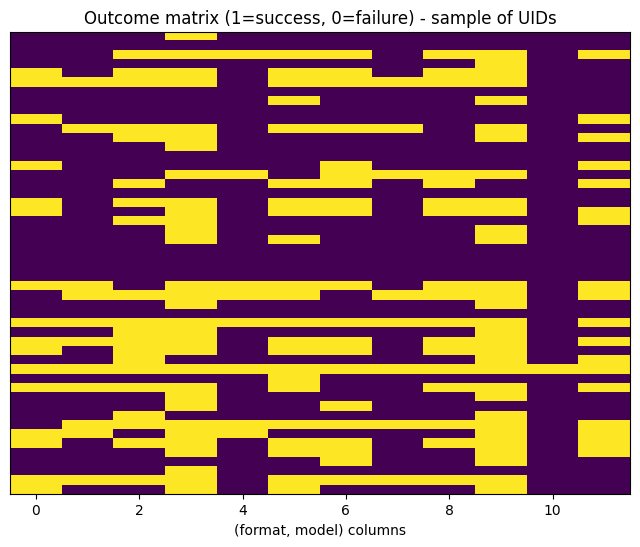

In [15]:
# === OPTIONAL: QUICK VISUALS (heatmap-like and counts) ===
# NOTE: As requested, we use matplotlib only, with no explicit color choices.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1) Per-format counts of successes per UID (across models)
format_success_counts = {}
for fmt in df.columns.get_level_values("format").unique():
    sub = df[fmt].fillna(False)
    format_success_counts[fmt] = sub.sum(axis=1)

counts_df = pd.DataFrame(format_success_counts)
ax = counts_df.sum().plot(kind="bar", title="Total successes per format (sum over UIDs)")
plt.xlabel("format"); plt.ylabel("#successes")
plt.show()

# 2) A simple boolean matrix visualization (UID x columns) for a small sample
sample = df.sample(min(50, len(df)), random_state=0).fillna(False)
matrix = sample.values.astype(int)

plt.figure(figsize=(8, 6))
plt.imshow(matrix, aspect='auto', interpolation='nearest')
plt.title("Outcome matrix (1=success, 0=failure) - sample of UIDs")
plt.yticks([])
plt.xlabel("(format, model) columns")
plt.show()

In [ ]:
ap = argparse.ArgumentParser(description="Join UID list with gold data and model attempts.")
ap.add_argument("--uids", required=True, help="Path to UID CSV (column 'uid' or first column).")
ap.add_argument("--parquet", required=True, help="Path to parquet with question/answer.")
ap.add_argument("--model", required=True, action="append",
                help=("Model JSON file(s). You can repeat --model multiple times. "
                        "Optionally name them as model_name=/path/to/file.json"))
ap.add_argument("--include-correct", action="store_true",
                help="Include successful attempts too (default shows only incorrect attempts).")
ap.add_argument("--out-csv", default=None, help="Path to write CSV.")
ap.add_argument("--out-html", default=None, help="Path to write HTML.")
ap.add_argument("--max-rows", type=int, default=50, help="Preview rows to print.")
args = ap.parse_args()

uid_idx = read_uid_csv(Path(args.uids))
gold = read_parquet_gold(Path(args.parquet))
models = load_models(args.model)

table = build_inspection_table(
    gold_df=gold,
    uid_list=uid_idx,
    models_df=models,
    only_incorrect=not args.include_correct
)

# Print a small preview
pd.set_option("display.max_colwidth", 120)
print(f"\nRows: {len(table)}  |  UIDs in list: {len(uid_idx)}  |  Models: {sorted(models['model'].unique())}\n")
print(table.head(args.max_rows).to_string(index=False))

# Save outputs
if args.out_csv:
    Path(args.out_csv).parent.mkdir(parents=True, exist_ok=True)
    table.to_csv(args.out_csv, index=False)
    print(f"\nSaved CSV -> {args.out_csv}")
if args.out_html:
    Path(args.out_html).parent.mkdir(parents=True, exist_ok=True)
    table.to_html(args.out_html, index=False, escape=False)
    print(f"Saved HTML -> {args.out_html}")
